# 7장 실습 — 시간과 기억

**대응 이론** 7장 「시간과 기억」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 4분)

4장부터 6장까지는 관측 하나에서 액션 하나를 뽑는 이야기였다. 실제 조작은 시간 위에서 벌어진다.

지금 카메라에 컵과 그리퍼가 보인다고 하자. 그리퍼가 컵으로 다가가는 중인가, 이미 집어서 들어 올리는 중인가. **한 장으로는 알 수 없다.** 그런데 두 경우의 정답 액션은 정반대다.

이 노트북에서 확인할 것은 넷이다.

1. 한 프레임이 만드는 모호성 — 그리고 그것이 왜 6장의 다봉 문제와 같은 것인지
2. 프레임을 몇 장 줄 것인가 — 많을수록 좋지 않다
3. 액션 청킹과 temporal ensembling — 추론 횟수와 부드러움의 거래
4. 프레임 히스토리로는 안 되는 것 — 장기 의존과 외부 메모리

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1 | threads 10


## 1. 한 프레임이 만드는 모호성

가장 단순한 형태로 문제를 만든다. 그리퍼가 좌우로 왕복하는 궤적이다. 관측은 그리퍼의 x 좌표와 물체의 x 좌표뿐이고, 액션은 속도와 그리퍼 개폐다.

핵심은 **같은 위치를 두 번 지난다**는 것이다. 오른쪽으로 갈 때 한 번, 왼쪽으로 돌아올 때 한 번. 관측은 똑같은데 정답 액션의 부호는 반대다.

이것이 6장에서 본 다봉 문제와 정확히 같은 구조라는 점을 짚어 둔다. 조건 하나에 정답이 둘이면 회귀는 가운데로 간다. 다만 6장에서는 다봉성이 데이터에 원래 있었고, 여기서는 **관측을 좁게 잘라서 우리가 만들어 낸 것**이다. 프레임을 한 장 더 주면 사라진다.

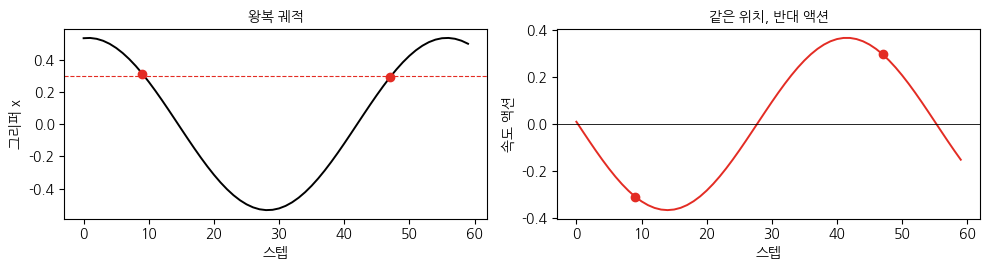

x = 0.3 을 지나는 스텝: [ 9 47] -> 속도: [-0.31  0.3 ]


In [2]:
T = 60

def episode(rng):
    A  = rng.uniform(.5, .9); ph = rng.uniform(0, 2*math.pi); w = rng.uniform(.85, 1.15)
    obj = rng.uniform(-.3, .3)
    t = np.arange(T + 8)
    x = A * np.sin(2*math.pi*w*t/T + ph)                       # 그리퍼 x
    obs = np.stack([x, np.full_like(x, obj)], 1).astype(np.float32)
    vx = np.diff(x) * 6.0
    grip = np.where(vx > 0, 1., -1.)                           # 진행 방향에 따라 열고 닫는다
    act = np.stack([np.clip(vx, -1, 1), grip], 1).astype(np.float32)
    return obs, act

def build(n, seed, K):
    rng = np.random.default_rng(seed); X, Y = [], []
    for _ in range(n):
        o, a = episode(rng)
        for t in range(K-1, T):
            X.append(o[t-K+1:t+1].reshape(-1)); Y.append(a[t])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

rng = np.random.default_rng(3)
o, a = episode(rng)
fig, ax = plt.subplots(1, 2, figsize=(10, 2.8))
ax[0].plot(o[:T, 0], color="k", lw=1.4); ax[0].axhline(0.3, color=RED, ls="--", lw=.8)
ax[0].set_xlabel("스텝"); ax[0].set_ylabel("그리퍼 x"); ax[0].set_title("왕복 궤적", fontsize=10)
hit = np.where(np.abs(o[:T, 0] - 0.3) < .02)[0]
for h in hit: ax[0].plot(h, o[h, 0], "o", color=RED, ms=6)
ax[1].plot(a[:T, 0], color=RED, lw=1.4)
for h in hit: ax[1].plot(h, a[h, 0], "o", color=RED, ms=6)
ax[1].axhline(0, color="k", lw=.6)
ax[1].set_xlabel("스텝"); ax[1].set_ylabel("속도 액션"); ax[1].set_title("같은 위치, 반대 액션", fontsize=10)
plt.tight_layout(); plt.show()
print("x = 0.3 을 지나는 스텝:", hit, "-> 속도:", np.round(a[hit, 0], 2))

In [3]:
class MLP(nn.Module):
    def __init__(s, in_dim, h=128, out=2):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(in_dim, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, out))
    def forward(s, x): return s.f(x)

def run_history(K, steps=1200, lr=3e-3, bs=256):
    Xtr, Ytr = build(300, 0, K); Xte, Yte = build(80, 7, K)
    torch.manual_seed(0); m = MLP(Xtr.shape[1])
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(Xtr), (bs,), generator=g)
        loss = F.smooth_l1_loss(m(Xtr[idx]), Ytr[idx], beta=.02)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    with torch.no_grad(): p = m(Xte)
    return dict(K=K, dim=Xtr.shape[1],
                vel=(p[:,0]-Yte[:,0]).abs().mean().item(),
                sign=((p[:,1]>0)==(Yte[:,1]>0)).float().mean().item())

hist = [run_history(K) for K in [1, 2, 3, 4, 6, 8]]
print(f"{'히스토리':<10}{'입력 차원':>10}{'속도 MAE':>11}{'그리퍼 부호 정확도':>18}")
print("-" * 51)
for r in hist:
    print(f"K={r['K']:<8}{r['dim']:10d}{r['vel']:11.4f}{r['sign']:17.0%}")
print("-" * 51)
print("K=1 의 부호 정확도 50% 는 동전 던지기다. 관측이 답을 정하지 못한다.")

히스토리           입력 차원     속도 MAE        그리퍼 부호 정확도
---------------------------------------------------
K=1                2     0.2811              51%
K=2                4     0.0066              98%
K=3                6     0.0063              98%
K=4                8     0.0082              98%
K=6               12     0.0121              97%
K=8               16     0.0140              98%
---------------------------------------------------
K=1 의 부호 정확도 50% 는 동전 던지기다. 관측이 답을 정하지 못한다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


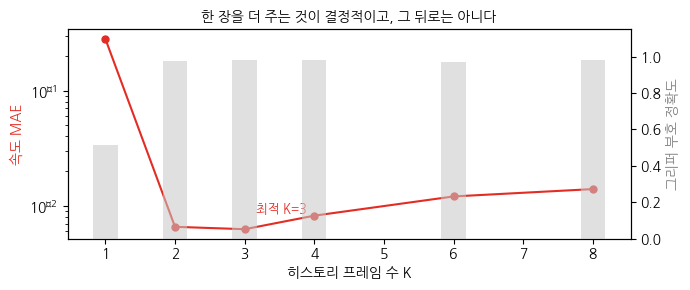

In [5]:
fig, ax1 = plt.subplots(figsize=(7, 3))
Ks = [r["K"] for r in hist]
ax1.plot(Ks, [r["vel"] for r in hist], color=RED, marker="o", ms=5)
ax1.set_xlabel("히스토리 프레임 수 K"); ax1.set_ylabel("속도 MAE", color=RED)
ax1.set_yscale("log")

best = min(hist, key=lambda r: r["vel"])
ax1.annotate(f"최적 K={best['K']}", (best["K"], best["vel"]),
             textcoords="offset points", xytext=(8, 12), fontsize=9, color=RED)
ax2 = ax1.twinx()
ax2.bar(Ks, [r["sign"] for r in hist], width=.35, color=GREY, alpha=.55)
ax2.set_ylabel("그리퍼 부호 정확도", color="gray"); ax2.set_ylim(0, 1.15)
ax1.set_title("한 장을 더 주는 것이 결정적이고, 그 뒤로는 아니다", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 프레임은 많을수록 좋지 않다

결과가 분명하다.

**K=1 에서 K=2 로 가는 한 걸음이 전부다.** 속도 오차가 40배 넘게 줄고 그리퍼 부호는 동전 던지기에서 98%가 된다. 속도를 알려면 위치 두 개면 충분하다는 당연한 이야기이고, 그 당연한 것이 없으면 정책이 원리적으로 불가능하다는 것도 같이 보여 준다.

**K를 더 늘리면 오히려 나빠진다.** K=6, K=8 에서 오차가 다시 오른다. 쓸모없는 과거가 입력 차원만 불리고, 어텐션이든 MLP든 유효한 신호를 희석한다. 지연도 함께 는다. 실제 VLA 연구가 2~4 프레임에서 합의한 이유이며, 이 노트북의 최적값도 그 범위 안에 있다.

여기서 중요한 것은 숫자 2가 아니라 **판단 기준**이다. 필요한 프레임 수는 "액션을 결정하는 데 필요한 시간 정보의 길이"가 정한다. 속도가 필요하면 2장, 가속도까지 필요하면 3장이다. 그보다 긴 의존은 프레임을 늘려 해결할 문제가 아니다. 4절에서 다룬다.

## 3. 액션 청킹 — 한 번에 여러 스텝을 내보낸다

지금까지는 매 스텝 한 번씩 추론했다. 3장의 ACT가 제안한 방식은 다르다. 한 번 추론할 때 **앞으로 H 스텝의 액션을 통째로** 내보낸다.

이유는 둘이다. 추론 횟수가 H분의 1로 줄고, 한 청크 안의 액션들이 서로 일관되므로 동작이 부드러워진다. 매 스텝 독립적으로 예측하면 관측 잡음이 그대로 액션 떨림으로 넘어간다.

실행 방식 세 가지를 비교한다.

- **매 스텝 예측** — 청킹 없이 매번 새로 뽑아 첫 액션만 쓴다
- **청크 개루프** — H 스텝치를 뽑아 그대로 다 실행하고, 다 쓰면 다시 뽑는다
- **청크 + temporal ensembling** — 매 스텝 새로 뽑되, 같은 시각을 예측한 여러 청크의 값을 가중 평균한다 (ACT 방식)

In [6]:
K, H = 2, 8

def chunk_episode(rng):
    A = rng.uniform(.5, .9); ph = rng.uniform(0, 2*math.pi); w = rng.uniform(.85, 1.15)
    t = np.arange(T + H + 4); x = A * np.sin(2*math.pi*w*t/T + ph)
    vx = np.clip(np.diff(x) * 6.0, -1, 1).astype(np.float32)
    return x.astype(np.float32), vx

def build_chunks(n, seed, noise=0.0):
    rng = np.random.default_rng(seed); X, Y = [], []
    for _ in range(n):
        x, v = chunk_episode(rng)
        xo = x + rng.normal(0, noise, x.shape).astype(np.float32)
        for t in range(K-1, T):
            X.append(xo[t-K+1:t+1]); Y.append(v[t:t+H])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

Xtr, Ytr = build_chunks(400, 0, 0.01)
torch.manual_seed(0); chunker = MLP(K, out=H); steps = 1500
opt = torch.optim.AdamW(chunker.parameters(), lr=3e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.OneCycleLR(opt, 3e-3, steps, pct_start=.15)
g = torch.Generator().manual_seed(1); t0 = time.time()
for i in range(steps):
    idx = torch.randint(0, len(Xtr), (256,), generator=g)
    loss = F.smooth_l1_loss(chunker(Xtr[idx]), Ytr[idx], beta=.02)
    opt.zero_grad(); loss.backward(); opt.step(); sch.step()
print(f"청크 예측기 학습 {time.time()-t0:.0f}s  (한 번에 {H} 스텝 예측)")

청크 예측기 학습 1s  (한 번에 8 스텝 예측)


In [7]:
NOISE = 0.03                       # 배포 환경의 관측 잡음
rng = np.random.default_rng(11)
res = {k: [] for k in ["매 스텝 예측", "청크 개루프", "청크 + 앙상블"]}
calls = {k: 0 for k in res}

for ep in range(40):
    x, v = chunk_episode(rng)
    xo = x + rng.normal(0, NOISE, x.shape).astype(np.float32)
    obs = torch.tensor(np.stack([xo[t-K+1:t+1] for t in range(K-1, T)]))
    with torch.no_grad(): ch = chunker(obs).numpy()          # (n, H)
    n = len(ch); truth = v[K-1:K-1+n]

    a1 = ch[:, 0]; calls["매 스텝 예측"] += n                 # 첫 액션만 사용
    a2 = np.zeros(n)                                          # H 스텝마다 한 번
    for s in range(0, n, H):
        a2[s:s+H] = ch[s, :min(H, n-s)]; calls["청크 개루프"] += 1
    a3 = np.zeros(n)                                          # 겹치는 예측을 가중 평균
    for t in range(n):
        vals = [ch[t-k, k] for k in range(min(H, t+1))]
        wts  = [math.exp(-0.3*k) for k in range(min(H, t+1))]
        a3[t] = np.average(vals, weights=wts)
    calls["청크 + 앙상블"] += n
    for k, a in zip(res, [a1, a2, a3]): res[k].append((a, truth))

print(f"{'실행 방식':<18}{'추적 MAE':>10}{'저크':>10}{'에피소드당 추론':>16}")
print("-" * 56)
summary = {}
for k, v_ in res.items():
    mae  = float(np.mean([np.abs(a-t).mean() for a, t in v_]))
    jerk = float(np.mean([np.abs(np.diff(a, 2)).mean() for a, t in v_]))
    summary[k] = (mae, jerk, calls[k]/40)
    print(f"{k:<18}{mae:10.4f}{jerk:10.4f}{calls[k]/40:14.1f}")
tj = float(np.mean([np.abs(np.diff(t, 2)).mean() for a, t in res["매 스텝 예측"]]))
print("-" * 56)
print(f"{'(정답 궤적)':<18}{0.0:10.4f}{tj:10.4f}{'-':>14}")

실행 방식                 추적 MAE        저크        에피소드당 추론
--------------------------------------------------------
매 스텝 예측               0.1913    0.6017          59.0
청크 개루프                0.1651    0.0545           8.0
청크 + 앙상블              0.0516    0.1142          59.0
--------------------------------------------------------
(정답 궤적)               0.0000    0.0029             -


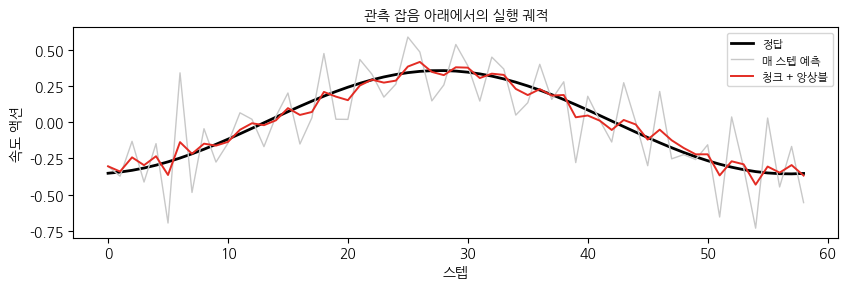

In [8]:
a1, truth = res["매 스텝 예측"][0]
a2 = res["청크 개루프"][0][0]; a3 = res["청크 + 앙상블"][0][0]
fig, ax = plt.subplots(figsize=(8.5, 3))
ax.plot(truth, color="k", lw=2, label="정답")
ax.plot(a1, color=GREY, lw=1, label="매 스텝 예측")
ax.plot(a3, color=RED, lw=1.4, label="청크 + 앙상블")
ax.set_xlabel("스텝"); ax.set_ylabel("속도 액션")
ax.legend(fontsize=8); ax.set_title("관측 잡음 아래에서의 실행 궤적", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 프레임 히스토리로 안 되는 것

여기까지의 이야기는 "몇 프레임이면 충분한가"였다. 그런데 프레임을 아무리 늘려도 안 되는 종류의 정보가 있다.

"서랍을 열고, 안에 있는 물건을 꺼내고, 서랍을 닫아라" 같은 과제를 생각해 보자. 서랍이 닫힌 장면만 보고는 **아직 안 열어 본 것인지 다 하고 닫은 것인지** 알 수 없다. 두 상황의 정답은 정반대인데, 그 차이는 수십 초 전에 벌어진 일에 있다.

아래에서 그 구조를 최소한으로 만든다. 에피소드 초반 두 프레임에만 신호가 켜지고, 30스텝 뒤부터 그 신호대로 행동해야 한다. 그 사이 관측에는 신호의 흔적이 없다.

In [9]:
T_M, CUE_T, ACT_T = 60, 10, 40

def make_memory_task(n, seed):
    rng = np.random.default_rng(seed)
    obs = np.zeros((n, T_M, 2), np.float32); act = np.zeros((n, T_M, 1), np.float32)
    for i in range(n):
        ph = rng.uniform(0, 2*math.pi)
        obs[i, :, 0] = 0.7 * np.sin(2*math.pi*np.arange(T_M)/T_M + ph)   # 늘 움직이는 위치
        c = rng.choice([-1., 1.])
        obs[i, CUE_T:CUE_T+2, 1] = c                                     # 두 프레임만 켜지는 신호
        act[i, :, 0] = obs[i, :, 0] * 0.3
        act[i, ACT_T:, 0] = c * 0.8                                      # 30스텝 뒤에 신호대로
    return torch.tensor(obs), torch.tensor(act)

MX, MY = make_memory_task(600, 0); TX_, TY_ = make_memory_task(200, 7)
print("신호는 t=%d~%d 두 프레임, 행동은 t>=%d 부터. 간격 %d 스텝."
      % (CUE_T, CUE_T+1, ACT_T, ACT_T-CUE_T-1))

class FrameHistory(nn.Module):
    def __init__(s, K, h=96):
        super().__init__(); s.K = K
        s.f = nn.Sequential(nn.Linear(2*K, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, 1))
    def forward(s, x):
        B, L, _ = x.shape
        pad = torch.cat([x[:, :1].expand(-1, s.K-1, -1), x], 1) if s.K > 1 else x
        w = torch.stack([pad[:, t:t+s.K].reshape(B, -1) for t in range(L)], 1)
        return s.f(w)

class LatchMemory(nn.Module):
    # 최소 외부 메모리: 쓰기 게이트가 열릴 때만 슬롯을 갱신하고, 매 스텝 읽는다.
    def __init__(s, msz=4, h=96, gate_bias=-5.0):
        super().__init__(); s.msz = msz
        s.gate = nn.Sequential(nn.Linear(2, 16), nn.GELU(), nn.Linear(16, 1))
        nn.init.constant_(s.gate[-1].bias, gate_bias)      # 기본은 닫힘 = 유지
        s.write = nn.Linear(2, msz)
        s.f = nn.Sequential(nn.Linear(2+msz, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, 1))
    def forward(s, x, ret_gate=False):
        B, L, _ = x.shape
        m = torch.zeros(B, s.msz); outs, gates = [], []
        for t in range(L):
            o = x[:, t]
            g = torch.sigmoid(s.gate(o))                   # 지금 기록할 것인가
            m = (1 - g) * m + g * torch.tanh(s.write(o))   # 슬롯 갱신
            outs.append(s.f(torch.cat([o, m], -1))); gates.append(g)
        out = torch.stack(outs, 1)
        return (out, torch.stack(gates, 1)) if ret_gate else out

def train_mem(m, steps=1200, lr=3e-3, bs=64):
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1); t0 = time.time()
    for i in range(steps):
        idx = torch.randint(0, len(MX), (bs,), generator=g)
        loss = F.smooth_l1_loss(m(MX[idx]), MY[idx], beta=.02)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return time.time() - t0

late = slice(ACT_T, T_M)
print(f"\n{'정책':<22}{'후반 MAE':>10}{'방향 정확도':>13}{'학습':>7}")
print("-" * 54)
for name, mk in [("프레임 1장", lambda: FrameHistory(1)),
                 ("프레임 4장", lambda: FrameHistory(4)),
                 ("프레임 8장", lambda: FrameHistory(8)),
                 ("외부 메모리", lambda: LatchMemory())]:
    torch.manual_seed(0); m = mk(); dt = train_mem(m)
    with torch.no_grad(): p = m(TX_)
    mae = (p[:, late] - TY_[:, late]).abs().mean().item()
    acc = ((p[:, late, 0] > 0) == (TY_[:, late, 0] > 0)).float().mean().item()
    print(f"{name:<22}{mae:10.4f}{acc:12.0%}{dt:6.0f}s")
    if name == "외부 메모리": mem_model = m

신호는 t=10~11 두 프레임, 행동은 t>=40 부터. 간격 29 스텝.

정책                        후반 MAE       방향 정확도     학습
------------------------------------------------------
프레임 1장                    0.8065         48%     2s
프레임 4장                    0.8065         48%     2s
프레임 8장                    0.8065         48%     3s
외부 메모리                    0.1658        100%    14s


프레임 1장                    0.8065         48%    10s


프레임 4장                    0.8065         48%     7s


프레임 8장                    0.8065         48%     7s


외부 메모리                    0.1656        100%    68s


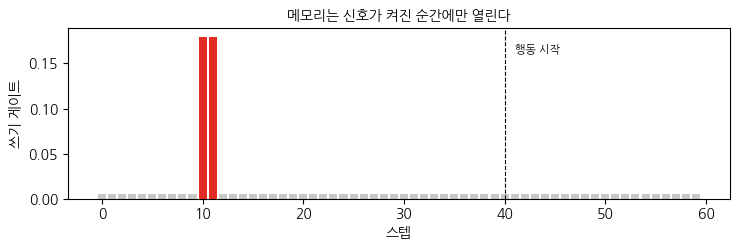

신호 프레임 게이트 0.180  /  나머지 평균 0.0058  -> 31배


In [10]:
with torch.no_grad(): _, gate = mem_model(TX_, ret_gate=True)
gp = gate[:, :, 0].mean(0).numpy()
plt.figure(figsize=(7.5, 2.6))
plt.bar(range(T_M), gp, color=[RED if t in (CUE_T, CUE_T+1) else GREY for t in range(T_M)])
plt.axvline(ACT_T, color="k", ls="--", lw=.8)
plt.text(ACT_T+1, gp.max()*.9, "행동 시작", fontsize=8)
plt.xlabel("스텝"); plt.ylabel("쓰기 게이트")
plt.title("메모리는 신호가 켜진 순간에만 열린다", fontsize=10)
plt.tight_layout(); plt.show()
print("신호 프레임 게이트 %.3f  /  나머지 평균 %.4f  -> %.0f배"
      % (gp[CUE_T:CUE_T+2].mean(), np.delete(gp, [CUE_T, CUE_T+1]).mean(),
         gp[CUE_T:CUE_T+2].mean() / np.delete(gp, [CUE_T, CUE_T+1]).mean()))

In [11]:
print(f"{'게이트 초기 편향':<18}{'초기 개방도':>12}{'30스텝 잔존율':>14}{'방향 정확도':>13}")
print("-" * 60)
for b in [-3.0, -5.0]:
    torch.manual_seed(0); m = LatchMemory(gate_bias=b); train_mem(m)
    with torch.no_grad(): p = m(TX_)
    acc = ((p[:, late, 0] > 0) == (TY_[:, late, 0] > 0)).float().mean().item()
    g0 = 1 / (1 + math.exp(-b))
    print(f"{b:<18.1f}{g0:12.3f}{(1-g0)**30:14.3f}{acc:12.0%}")
print("-" * 60)
print("0.05 씩 덮어쓰는 것만으로 30스텝이면 신호가 사라진다.")

게이트 초기 편향               초기 개방도      30스텝 잔존율       방향 정확도
------------------------------------------------------------
-3.0                     0.047         0.233         50%
-5.0                     0.007         0.818        100%
------------------------------------------------------------
0.05 씩 덮어쓰는 것만으로 30스텝이면 신호가 사라진다.


-3.0                     0.047         0.233         50%


-5.0                     0.007         0.818        100%
------------------------------------------------------------
0.05 씩 덮어쓰는 것만으로 30스텝이면 신호가 사라진다.


### 다음 장으로
3부에서는 그 좌표계 위에 실제 모델을 얹는다. RT-2가 무엇을 처음 했고 무엇을 지불했는지, OpenVLA가 그것을 어떻게 오픈 웨이트로 재현했는지, π0가 왜 토큰을 버렸는지, 휴머노이드 모델들이 왜 시스템을 둘로 나누는지를 지금까지 세운 기준으로 읽는다.